# OrganBagTransformer (OBT) — Boundary-Slice Yönlendirmeli Çok-Görevli CT Modeli
### Kaggle Notebook (Birincil) · Google Colab (İkincil)

**Mimari:**
```
CT hacmi → ConvNeXt-S encoder → Organ Bag çıkarma (boundary-slice)
         → DETR-tarzı organ dikkat → Cross-organ Transformer
         → Hasta-düzeyi / Dilim-düzeyi / FCOS tespit / Triyaj
```

**Yenilik:** Boundary-slice etiketleri (normalde atılan) → organ bag yapısına dönüştürülür;
6 organ token cross-organ attention ile birbirleriyle konuşur (GNN'nin co-occurrence
sorununu olmadan geçer — sadece 6 token).

| Aşama | Süre (A100) |
|---|---|
| Stage 0 — Prior fitting | ~5 dk |
| Stage 1 — ConvNeXt + FCOS | ~3-4 saat |
| Stage 2 — OrganBag + CrossOrgan | ~2 saat |
| Stage 3 — Joint fine-tune | ~3-4 saat |

> **Not:** Stage 1 bitmeden Stage 2 başlatmayın. `STAGE = 1/2/3` değiştirerek devam edilebilir.

---
## 0. Ortam Tespiti ve GPU Kontrolü

In [1]:
import os, sys, subprocess
from pathlib import Path

IS_KAGGLE = os.path.exists('/kaggle/working')
IS_COLAB  = not IS_KAGGLE and os.path.exists('/content')
IS_LOCAL  = not IS_KAGGLE and not IS_COLAB
env_name  = 'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Local'
print(f'Ortam : {env_name}')

import torch
if torch.cuda.is_available():
    print(f'GPU   : {torch.cuda.get_device_name(0)}')
    print(f'VRAM  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    DEVICE = torch.device('cuda')
elif IS_LOCAL and torch.backends.mps.is_available():
    print('GPU   : Apple Silicon MPS')
    DEVICE = torch.device('mps')
else:
    print('UYARI: GPU yok — CPU ile çok yavaş olur')
    DEVICE = torch.device('cpu')
print(f'PyTorch: {torch.__version__}')

Ortam : Local
GPU   : Apple Silicon MPS
PyTorch: 2.8.0


---
## 1. Colab Kurulumu (Kaggle'da atlanır)

In [2]:
if IS_COLAB:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle'], check=True)
    try:
        from google.colab import userdata, drive
        os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')
        drive.mount('/content/drive', force_remount=False)
        print('Kaggle + Drive hazır')
    except Exception as e:
        print(f'Manuel kurulum gerekebilir: {e}')
else:
    print(f'{env_name} — Colab kurulumu atlandı')

Local — Colab kurulumu atlandı


---
## 2. Kütüphane Kurulumu

In [3]:
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'timm>=0.9.16', 'torchvision', 'pandas', 'numpy',
     'scipy', 'scikit-learn', 'tqdm', 'matplotlib', 'pillow'],
    check=True
)
import importlib; importlib.invalidate_caches()
import timm
print(f'timm  : {timm.__version__}')
print(f'torch : {torch.__version__}')

timm  : 1.0.26
torch : 2.8.0


---
## 3. Konfigürasyon

In [4]:
import json, shutil, time
import numpy as np
import pandas as pd
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple

# .env varsa yükle (LOCAL için önemli — Kaggle/Colab'da yok)
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# ─── Kullanıcı Ayarları ────────────────────────────────────────────────────
KAGGLE_DATASET_ID   = 'ramazan2020/abdomen-acikveri'
KAGGLE_DATASET_SLUG = 'abdomen-acikveri'
GITHUB_URL          = 'https://github.com/ramazan2020/abdomen1.git'
FOLD   = 0
STAGE  = 1       # Çalıştırılacak aşama: 1 | 2 | 3
# ──────────────────────────────────────────────────────────────────────────

SUPER_CLASSES = [
    'acute_cholecystitis', 'kidney_ureter_stone', 'acute_pancreatitis',
    'aortic_aneurysm_dissection', 'acute_appendicitis', 'acute_diverticulitis',
]
ANATOMICAL_CLASSES = [
    'Abdominal Aorta', 'Gall bladder', 'Pancreas',
    'Kidney-Bladder', 'Colon', 'appendix',
]

# ─── Ortam yolları (.env > hesaplama) ────────────────────────────────────
if IS_KAGGLE:
    DATA_DIR     = Path('/kaggle/input') / KAGGLE_DATASET_SLUG
    WORK_DIR     = Path('/kaggle/working')
    SPLIT_DIR    = WORK_DIR / 'splits'
    DET_DATA_DIR = DATA_DIR / 'det_data'

elif IS_COLAB:
    DATA_DIR     = Path('/content/kaggle_data')
    WORK_DIR     = Path('/content')
    SPLIT_DIR    = WORK_DIR / 'splits'
    DET_DATA_DIR = DATA_DIR / 'det_data'
    DRIVE_BASE   = Path('/content/drive/MyDrive/Abdomen')
    DRIVE_BASE.mkdir(parents=True, exist_ok=True)

else:  # LOCAL — .env değerlerini kullan
    _proje       = Path(os.environ.get('TR_ABDOMEN_PROJE',    r'D:/makale-pdf/Proje'))
    WORK_DIR     = Path(os.environ.get('ABDOMEN_OUT_DIR',     str(_proje / 'outputs')))
    SPLIT_DIR    = Path(os.environ.get('ABDOMEN_SPLIT_DIR',   str(WORK_DIR / 'splits')))
    DET_DATA_DIR = Path(os.environ.get('ABDOMEN_DET_DATA_DIR',str(WORK_DIR / 'det_data')))
    DATA_DIR     = Path(os.environ.get('TR_ABDOMEN_BASE',     str(_proje / 'abdomen')))

OBT_DIR  = WORK_DIR / f'obt_fold{FOLD}'
CKPT_DIR = OBT_DIR / 'checkpoints'
LOG_DIR  = OBT_DIR / 'logs'
OUT_DIR  = OBT_DIR / 'output'

for d in [OBT_DIR, CKPT_DIR, LOG_DIR, OUT_DIR, SPLIT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f'Ortam       : {env_name}')
print(f'DATA_DIR    : {DATA_DIR}  ({"✓" if DATA_DIR.exists() else "✗"})')
print(f'WORK_DIR    : {WORK_DIR}  ({"✓" if WORK_DIR.exists() else "✗"})')
print(f'SPLIT_DIR   : {SPLIT_DIR}  ({"✓" if SPLIT_DIR.exists() else "✗"})')
print(f'DET_DATA_DIR: {DET_DATA_DIR}  ({"✓" if DET_DATA_DIR.exists() else "✗"})')
print(f'OBT_DIR     : {OBT_DIR}')
print(f'Stage       : {STAGE}')

Ortam       : Local
DATA_DIR    : /Users/ramazanpolat/Desktop/datasets/abdomenDataSet  (✓)
WORK_DIR    : /Users/ramazanpolat/Desktop/datasets/abdomen/outputs  (✓)
SPLIT_DIR   : /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/splits  (✓)
DET_DATA_DIR: /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/det_data  (✓)
OBT_DIR     : /Users/ramazanpolat/Desktop/datasets/abdomen/outputs/obt_fold0
Stage       : 1


---
## 4. GitHub Repo + src Import

In [5]:
if IS_LOCAL:
    REPO_DIR = Path(__file__).resolve().parent if '__file__' in dir() else Path('.').resolve()
    print(f'Local: src/ → {REPO_DIR / "src"}')
else:
    REPO_DIR = WORK_DIR / 'abdomen1'
    if not (REPO_DIR / '.git').exists():
        print(f'Klonlanıyor: {GITHUB_URL}')
        subprocess.run(['git', 'clone', '--depth=1', GITHUB_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(['git', '-C', str(REPO_DIR), 'pull', '--ff-only'], capture_output=True)
    print(f'Repo: {REPO_DIR}')

if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from src.organ_bag_transformer import (
    OrganBagTransformer, OBTConfig, OBTLoss,
    build_z_ranges_from_annotations,
    decode_fcos_output, compute_triage_score, compute_uncertainty,
    ANATOMICAL_DEFAULT_Z_FRACS, CLASS_TO_ORGAN_IDX,
)
from src.evaluation  import f1_at_iou, top5_f1_mean
from src.splits      import load_merged_annotations
from src.losses      import compute_class_balanced_alpha

print('src.organ_bag_transformer ✓')
print('src.evaluation ✓')

Local: src/ → /Users/ramazanpolat/Desktop/datasets/abdomen/src
src.organ_bag_transformer ✓
src.evaluation ✓


---
## 5. Veri İndirme (Yalnızca Colab)

In [6]:
if IS_KAGGLE:
    print('Kaggle: Dataset zaten mount edilmiş')
elif IS_COLAB:
    if not DATA_DIR.exists() or not any(DATA_DIR.iterdir()):
        DATA_DIR.mkdir(parents=True, exist_ok=True)
        print(f'Dataset indiriliyor: {KAGGLE_DATASET_ID}')
        r = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', KAGGLE_DATASET_ID,
             '-p', str(DATA_DIR), '--unzip'],
            capture_output=True, text=True
        )
        if r.returncode != 0:
            print('HATA:', r.stderr[-500:])
            raise RuntimeError('Dataset indirilemedi')
        print('İndirildi ✓')
    else:
        print(f'Dataset mevcut: {DATA_DIR}')
else:
    print(f'Local: {DATA_DIR}')

Local: /Users/ramazanpolat/Desktop/datasets/abdomenDataSet


---
## 6. Manifest ve Boundary Anotasyonları Yükle

In [7]:
_manifest_csv = SPLIT_DIR / 'manifest.csv'

# Bilgi.xlsx — LOCAL: .env ABDOMEN_BILGI_XLSX, Kaggle/Colab: DATA_DIR içinde
_bilgi_path = Path(os.environ.get('ABDOMEN_BILGI_XLSX', str(DATA_DIR / 'Bilgi.xlsx')))
if not _bilgi_path.exists():
    _candidates = list(DATA_DIR.rglob('Bilgi.xlsx'))
    if _candidates:
        _bilgi_path = _candidates[0]
    else:
        raise FileNotFoundError(
            f'Bilgi.xlsx bulunamadı.\n'
            f'  ABDOMEN_BILGI_XLSX={os.environ.get("ABDOMEN_BILGI_XLSX","<set edilmemiş>")}\n'
            f'  DATA_DIR={DATA_DIR}'
        )
print(f'Bilgi.xlsx  : {_bilgi_path}  ({"✓" if _bilgi_path.exists() else "✗"})')

# Manifest
if not _manifest_csv.exists():
    print('manifest.csv oluşturuluyor...')
    from src.preprocessing import build_manifest
    build_manifest(_manifest_csv)
manifest_df = pd.read_csv(_manifest_csv)
# manifest.csv kolon adı: 'case' (case_id değil)
print(f'manifest.csv: {len(manifest_df):,} satır, {manifest_df["case"].nunique()} vaka')

# Splits — CSV'leri doğrudan notebook SPLIT_DIR'den oku (config.py bağımsız)
_fold_train_csv = SPLIT_DIR / f'fold{FOLD}_train.csv'
_fold_val_csv   = SPLIT_DIR / f'fold{FOLD}_val.csv'

if not _fold_train_csv.exists():
    print('Splits oluşturuluyor...')
    from src.splits import make_splits
    make_splits(out_dir=SPLIT_DIR)

train_cases = pd.read_csv(_fold_train_csv)['Case Number'].astype(str).tolist()
val_cases   = pd.read_csv(_fold_val_csv)['Case Number'].astype(str).tolist()
print(f'Fold {FOLD}: train={len(train_cases)} vaka, val={len(val_cases)} vaka')

# Bilgi.xlsx — boundary slice anotasyonları
bilgi_sheets = pd.read_excel(_bilgi_path, sheet_name=None)
_train_raw = bilgi_sheets['TRAIININGDATA'].copy()
_train_raw['Case Number'] = _train_raw['Case Number'].apply(lambda x: f'T_{x}')
_comp_raw  = bilgi_sheets['COMPETITIONDATA'].copy()
_comp_raw['Case Number']  = _comp_raw['Case Number'].apply(lambda x: f'C_{x}')
bilgi_df = pd.concat([_train_raw, _comp_raw], ignore_index=True)

boundary_df = bilgi_df[bilgi_df['Type'] == 'Boundary Slice'].copy()
bb_df       = bilgi_df[bilgi_df['Type'] == 'Bounding Box'].copy()
print(f'Boundary Slice: {len(boundary_df):,}  |  Bounding Box: {len(bb_df):,}')

Bilgi.xlsx  : /Users/ramazanpolat/Desktop/datasets/abdomenDataSet/Bilgi.xlsx  (✓)
manifest.csv: 39,268 satır, 1092 vaka
Fold 0: train=580 vaka, val=145 vaka
Boundary Slice: 7,898  |  Bounding Box: 34,550


---
## 7. Stage 0 — Organ Bag İstatistikleri ve KDE Prior (Şekil 1)

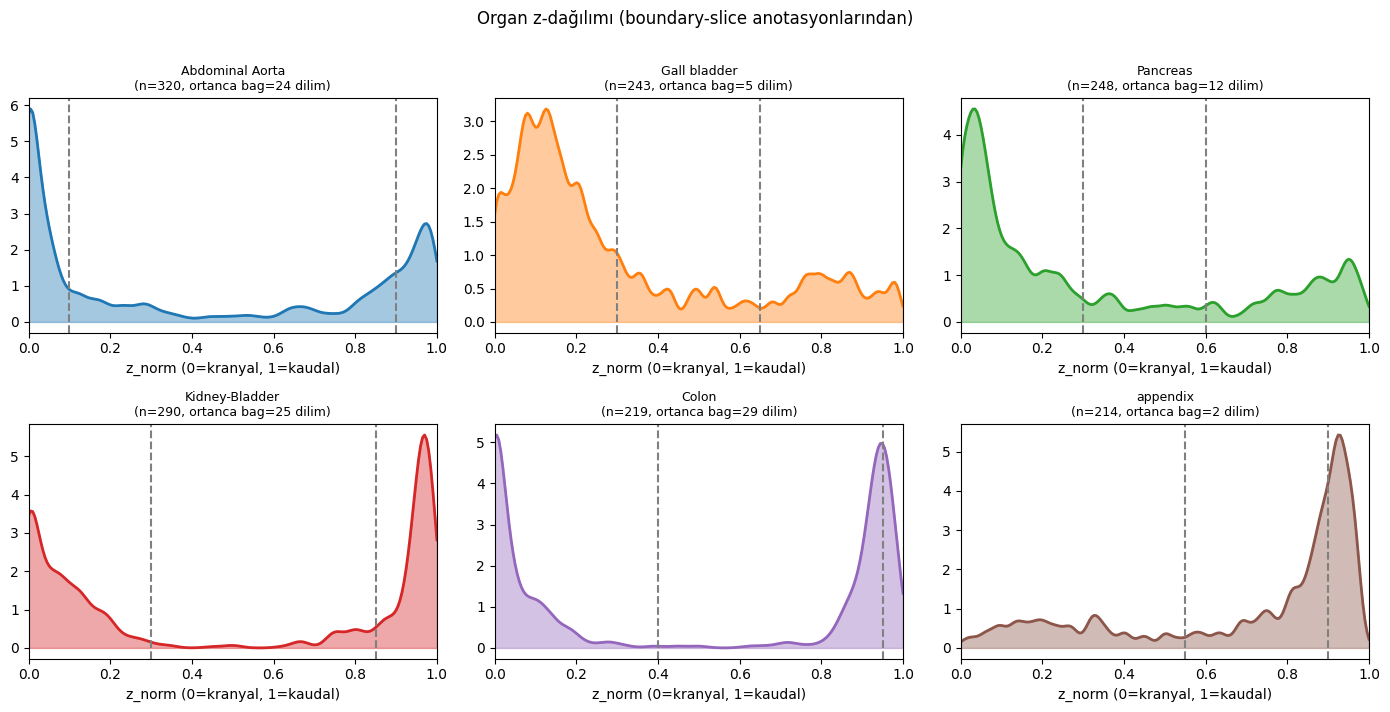

Şekil 1 kaydedildi.

Organ                    Anotasyonlu vaka   Ortanca bag
--------------------------------------------------------
  Abdominal Aorta                     320            24
  Gall bladder                        243             5
  Pancreas                            248            12
  Kidney-Bladder                      290            25
  Colon                               219            29
  appendix                            214             2


In [8]:
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Her vaka için image_id sıralamasını belirle
# manifest.csv kolonları: 'case', 'image_id' (case_id değil)
case_image_ids = (
    manifest_df
    .sort_values(['case', 'image_id'])
    .groupby('case')['image_id']
    .apply(list)
    .to_dict()
)

# Her organ için normalized z-pozisyonlarını topla
organ_z_norms: Dict[int, List[float]] = {k: [] for k in range(6)}
organ_bag_lengths: Dict[int, List[int]] = {k: [] for k in range(6)}

train_set = set(train_cases)
for case_id, img_ids in case_image_ids.items():
    if case_id not in train_set:
        continue
    D = len(img_ids)
    if D == 0:
        continue
    id_to_z = {int(iid): z for z, iid in enumerate(img_ids)}
    case_boundary = boundary_df[boundary_df['Case Number'] == case_id]

    for organ_idx, organ_name in enumerate(ANATOMICAL_CLASSES):
        organ_rows = case_boundary[case_boundary['Class'] == organ_name]
        z_pos = [id_to_z[int(iid)] for iid in organ_rows['Image Id'] if int(iid) in id_to_z]
        if len(z_pos) >= 2:
            z_s, z_e = min(z_pos), max(z_pos)
            organ_z_norms[organ_idx].extend([z_s / D, z_e / D])
            organ_bag_lengths[organ_idx].append(z_e - z_s + 1)

# Görselleştir
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
z_grid = np.linspace(0, 1, 200)

for k, (ax, organ_name) in enumerate(zip(axes, ANATOMICAL_CLASSES)):
    zn = organ_z_norms[k]
    if len(zn) > 5:
        kde = gaussian_kde(zn, bw_method=0.05)
        ax.fill_between(z_grid, kde(z_grid), alpha=0.4, color=f'C{k}')
        ax.plot(z_grid, kde(z_grid), color=f'C{k}', lw=2)
        frac_s, frac_e = ANATOMICAL_DEFAULT_Z_FRACS[k]
        ax.axvline(frac_s, color='gray', lw=1.5, ls='--', label='Fallback')
        ax.axvline(frac_e, color='gray', lw=1.5, ls='--')
    median_len = np.median(organ_bag_lengths[k]) if organ_bag_lengths[k] else 0
    ax.set_title(f'{organ_name}\n(n={len(organ_bag_lengths[k])}, ortanca bag={median_len:.0f} dilim)', fontsize=9)
    ax.set_xlabel('z_norm (0=kranyal, 1=kaudal)')
    ax.set_xlim(0, 1)

plt.suptitle('Organ z-dağılımı (boundary-slice anotasyonlarından)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'fig1_organ_z_distribution.pdf'), bbox_inches='tight', dpi=150)
plt.show()
print('Şekil 1 kaydedildi.')

print(f'\n{"Organ":<22} {"Anotasyonlu vaka":>18} {"Ortanca bag":>13}')
print('-' * 56)
for k, name in enumerate(ANATOMICAL_CLASSES):
    n   = len(organ_bag_lengths[k])
    med = np.median(organ_bag_lengths[k]) if organ_bag_lengths[k] else 0
    print(f'  {name:<20} {n:>18}  {med:>12.0f}')

---
## 8. Model Kurulumu

In [9]:
# Sınıf ağırlıkları (eğitim setindeki pozitif vaka sayısından)
from src.splits import load_merged_annotations
from src.config import super_id_from_raw

_all_ann  = load_merged_annotations()
_train_bb = _all_ann[
    (_all_ann['Type'] == 'Bounding Box') &
    (_all_ann['Case Number'].isin(train_cases))
].copy()
_train_bb['super_id'] = _train_bb['Class'].map(super_id_from_raw)
_train_bb = _train_bb.dropna(subset=['super_id'])
pos_counts = [
    _train_bb[_train_bb['super_id'] == k]['Case Number'].nunique()
    for k in range(6)
]
print(f'Pozitif vaka sayıları: {pos_counts}')

class_weights = compute_class_balanced_alpha(pos_counts, total=len(train_cases))
# torch.Tensor.round() bu PyTorch sürümünde ondalık argümanı almıyor → numpy
print(f'Sınıf ağırlıkları: {class_weights.numpy().round(3).tolist()}')

# OBTConfig
cfg = OBTConfig(
    encoder='convnext_small.fb_in22k_ft_in1k',
    d_model=256,
    n_cross_organ_heads=8,
    n_cross_organ_layers=4,
    fcos_stacks=4,
    gate_alpha_init=0.0,
    dropout=0.1,
    encoder_pretrained=True,
)

model = OrganBagTransformer(cfg).to(DEVICE)
n_total = sum(p.numel() for p in model.parameters())
n_enc   = sum(p.numel() for p in model.encoder.parameters())
n_new   = n_total - n_enc
print(f'\nParametre sayıları:')
print(f'  Encoder (ConvNeXt-S) : {n_enc/1e6:.1f}M')
print(f'  Yeni modüller        : {n_new/1e6:.1f}M')
print(f'  TOPLAM               : {n_total/1e6:.1f}M')

criterion = OBTLoss(
    lambda_patient=1.0,
    lambda_slice=0.5,
    lambda_det_cls=0.3,
    lambda_det_box=0.3,
    lambda_centerness=0.1,
    class_weights=class_weights,
)
print('OBTLoss ✓')

Pozitif vaka sayıları: [151, 168, 136, 136, 56, 14]
Sınıf ağırlıkları: [0.2549999952316284, 0.23600000143051147, 0.2750000059604645, 0.2750000059604645, 0.4790000021457672, 0.7860000133514404]

Parametre sayıları:
  Encoder (ConvNeXt-S) : 49.5M
  Yeni modüller        : 8.9M
  TOPLAM               : 58.4M
OBTLoss ✓


/Users/ramazanpolat/Desktop/datasets/abdomen/.venv/lib/python3.9/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


---
## 9. Stage 1 — ConvNeXt + FCOS Eğitimi (Dilim-Düzeyi)

Organ bag ve cross-organ modülleri dondurulmuş; yalnızca encoder + FCOS başlığı eğitilir.

In [10]:
# YOLO PNG dosyalarından dilim dataseti
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader

YOLO_FOLD_DIR  = DET_DATA_DIR / f'fold{FOLD}'
TRAIN_IMG_DIR  = YOLO_FOLD_DIR / 'images' / 'train'
TRAIN_LBL_DIR  = YOLO_FOLD_DIR / 'labels' / 'train'
VAL_IMG_DIR    = YOLO_FOLD_DIR / 'images' / 'val'
VAL_LBL_DIR    = YOLO_FOLD_DIR / 'labels' / 'val'

if not TRAIN_IMG_DIR.exists():
    print(f'YOLO PNG bulunamadı: {TRAIN_IMG_DIR}')
    print('Önce Faz3_YOLO_Colab_Kaggle.ipynb veri hazırlık hücresini çalıştırın.')
else:
    print(f'train PNG: {len(list(TRAIN_IMG_DIR.glob("*.png"))):,}')
    print(f'val   PNG: {len(list(VAL_IMG_DIR.glob("*.png"))):,}')

train PNG: 20,964
val   PNG: 5,470


In [11]:
IMG_SIZE = 512
STRIDE   = 32
FEAT_H   = IMG_SIZE // STRIDE   # 16
FEAT_W   = IMG_SIZE // STRIDE   # 16

TRAIN_TRANSFORM = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.0),  # CT'de flip yok (anatomik simetri bozulur)
    T.ColorJitter(brightness=0.2),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])
VAL_TRANSFORM = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

def _parse_stem(stem):
    parts = stem.split('_')
    return int(parts[1]), int(parts[2])

def _make_fcos_target(boxes_xyxy, cls_ids, img_size=512, stride=32):
    """YOLO kutularından basit FCOS hedef map'leri üretir."""
    FH = img_size // stride
    cls_map = np.zeros((6, FH, FH), dtype=np.float32)
    box_map = np.zeros((4, FH, FH), dtype=np.float32)
    pos_mask   = np.zeros((FH, FH), dtype=bool)
    ctr_map    = np.zeros((1, FH, FH), dtype=np.float32)

    for (x1, y1, x2, y2), c in zip(boxes_xyxy, cls_ids):
        cx = (x1 + x2) / 2
        cy = (y1 + y2) / 2
        gi = int(cx // stride)
        gj = int(cy // stride)
        gi = min(gi, FH - 1)
        gj = min(gj, FH - 1)

        # Center cell pozitif
        cls_map[c, gj, gi] = 1.0
        pos_mask[gj, gi] = True

        # ltrb (piksel cinsinden, feature map ölçeğinde)
        cell_cx = gi * stride + stride / 2
        cell_cy = gj * stride + stride / 2
        box_map[0, gj, gi] = cell_cx - x1   # left
        box_map[1, gj, gi] = cell_cy - y1   # top
        box_map[2, gj, gi] = x2 - cell_cx   # right
        box_map[3, gj, gi] = y2 - cell_cy   # bottom

        # Centerness
        l, t, r, b = box_map[0, gj, gi], box_map[1, gj, gi], box_map[2, gj, gi], box_map[3, gj, gi]
        if l > 0 and t > 0 and r > 0 and b > 0:
            ctr = np.sqrt((min(l,r) / max(l,r)) * (min(t,b) / max(t,b)))
            ctr_map[0, gj, gi] = float(ctr)

    return {
        'cls_map':       torch.from_numpy(cls_map),
        'box_map':       torch.from_numpy(box_map),
        'pos_mask':      torch.from_numpy(pos_mask),
        'centerness_map': torch.from_numpy(ctr_map),
    }


class FCOSSliceDataset(Dataset):
    """YOLO PNG + label → (image, slice_labels, fcos_targets)."""

    def __init__(self, img_dir: Path, lbl_dir: Path, transform=None):
        self.img_paths = sorted(img_dir.glob('*.png'))
        self.lbl_dir   = lbl_dir
        self.transform = transform or VAL_TRANSFORM

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        ip  = self.img_paths[idx]
        img = Image.open(ip).convert('RGB')
        W, H = img.size
        img_t = self.transform(img)  # (3, IMG_SIZE, IMG_SIZE)

        lp = self.lbl_dir / (ip.stem + '.txt')
        boxes, cls_ids = [], []
        slice_label = np.zeros(6, dtype=np.float32)

        if lp.exists():
            for line in lp.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) < 5:
                    continue
                c = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw/2) * IMG_SIZE
                y1 = (cy - bh/2) * IMG_SIZE
                x2 = (cx + bw/2) * IMG_SIZE
                y2 = (cy + bh/2) * IMG_SIZE
                boxes.append([x1, y1, x2, y2])
                cls_ids.append(c)
                slice_label[c] = 1.0

        fcos = _make_fcos_target(boxes, cls_ids) if boxes else _make_fcos_target([], [])
        return img_t, torch.from_numpy(slice_label), fcos, ip.stem


def _collate_fcos(batch):
    imgs   = torch.stack([b[0] for b in batch])
    labels = torch.stack([b[1] for b in batch])
    keys   = batch[0][2].keys()
    fcos   = {k: torch.stack([b[2][k] for b in batch]) for k in keys}
    stems  = [b[3] for b in batch]
    return imgs, labels, fcos, stems


BATCH_S1 = 8
train_ds_s1 = FCOSSliceDataset(TRAIN_IMG_DIR, TRAIN_LBL_DIR, TRAIN_TRANSFORM)
val_ds_s1   = FCOSSliceDataset(VAL_IMG_DIR, VAL_LBL_DIR, VAL_TRANSFORM)
# num_workers=0: sınıf notebook hücresinde tanımlı (__main__) — macOS'ta
# spawn ile başlatılan worker process'ler onu import edemediği için
# "Can't get attribute 'FCOSSliceDataset' on <module '__main__'>" hatası verir.
train_dl_s1 = DataLoader(train_ds_s1, batch_size=BATCH_S1, shuffle=True,
                          num_workers=0, collate_fn=_collate_fcos)
val_dl_s1   = DataLoader(val_ds_s1, batch_size=BATCH_S1, shuffle=False,
                          num_workers=0, collate_fn=_collate_fcos)
print(f'Train dataset: {len(train_ds_s1):,} dilim, {len(train_dl_s1)} batch')
print(f'Val   dataset: {len(val_ds_s1):,} dilim, {len(val_dl_s1)} batch')

Train dataset: 20,964 dilim, 2621 batch
Val   dataset: 5,470 dilim, 684 batch


In [ ]:
from tqdm.notebook import tqdm

EPOCHS_S1 = 30
S1_CKPT   = CKPT_DIR / 'stage1_best.pt'

if STAGE < 1:
    print('Stage 1 atlandı (STAGE < 1)')
elif S1_CKPT.exists() and STAGE > 1:
    print(f'Stage 1 checkpoint mevcut: {S1_CKPT}')
    model.load_state_dict(torch.load(str(S1_CKPT), map_location=DEVICE))
    print('Stage 1 ağırlıkları yüklendi, Stage 2/3 için devam ediliyor.')
else:
    # Stage 1: encoder + FCOS eğitilir, organ bag / cross-organ dondurulur
    for p in model.organ_bag_attn.parameters(): p.requires_grad_(False)
    for p in model.cross_organ_tf.parameters(): p.requires_grad_(False)
    for p in model.patient_head.parameters():   p.requires_grad_(False)

    # Stage 1'de hasta kaybı hesaplanmaz — case_forward yok
    criterion_s1 = OBTLoss(
        lambda_patient=0.0,
        lambda_slice=0.5,
        lambda_det_cls=0.3,
        lambda_det_box=0.3,
        lambda_centerness=0.1,
        class_weights=class_weights,
    )
    _dummy_patient = torch.zeros(6, device=DEVICE)

    opt_s1 = torch.optim.AdamW([
        {'params': model.encoder.parameters(),   'lr': 1e-4},
        {'params': model.chan_proj.parameters(),  'lr': 1e-4},
        {'params': model.fcos_head.parameters(),  'lr': 1e-3},
    ], weight_decay=1e-4)
    sched_s1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s1, T_max=EPOCHS_S1)

    best_val_loss = float('inf')
    for epoch in range(1, EPOCHS_S1 + 1):
        model.train()
        train_loss = 0.0
        for imgs, labels, fcos_tgt, _ in tqdm(train_dl_s1, desc=f'S1 E{epoch}', leave=False):
            imgs     = imgs.to(DEVICE)
            labels   = labels.to(DEVICE)
            fcos_tgt = {k: v.to(DEVICE) for k, v in fcos_tgt.items()}

            cls_l, reg_l, ctr_l = model.fcos_forward(imgs)
            loss, _ = criterion_s1(
                patient_logits=_dummy_patient,
                patient_labels=_dummy_patient,
                slice_logits=cls_l,
                slice_labels=labels,
                fcos_cls=cls_l,
                fcos_box=reg_l,
                fcos_ctr=ctr_l,
                box_targets=fcos_tgt,
            )
            opt_s1.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt_s1.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for imgs, labels, fcos_tgt, _ in val_dl_s1:
                imgs     = imgs.to(DEVICE)
                labels   = labels.to(DEVICE)
                fcos_tgt = {k: v.to(DEVICE) for k, v in fcos_tgt.items()}
                cls_l, reg_l, ctr_l = model.fcos_forward(imgs)
                loss, _ = criterion_s1(
                    patient_logits=_dummy_patient,
                    patient_labels=_dummy_patient,
                    slice_logits=cls_l,
                    slice_labels=labels,
                    fcos_cls=cls_l,
                    fcos_box=reg_l,
                    fcos_ctr=ctr_l,
                    box_targets=fcos_tgt,
                )
                val_loss += loss.item()

        avg_train = train_loss / len(train_dl_s1)
        avg_val   = val_loss / len(val_dl_s1)
        sched_s1.step()

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), str(S1_CKPT))

        if epoch % 5 == 0:
            print(f'Epoch {epoch:3d}/{EPOCHS_S1}  '
                  f'train={avg_train:.4f}  val={avg_val:.4f}  '
                  f'best_val={best_val_loss:.4f}')

    print(f'\nStage 1 tamamlandı. Best val loss: {best_val_loss:.4f}')
    print(f'Checkpoint: {S1_CKPT}')
    for p in model.parameters(): p.requires_grad_(True)

S1 E1:   0%|          | 0/2621 [00:00<?, ?it/s]

---
## 10. Stage 2 — OrganBag + CrossOrgan Eğitimi (Hasta-Düzeyi)

Encoder dondurulmuş; yalnızca `organ_bag_attn`, `cross_organ_tf`, `patient_head` eğitilir.

In [ ]:
# Hasta-düzeyi veri yapısı: vaka başına tüm dilim PNG'leri + hasta etiketi

def _get_case_patient_label(case_id):
    """Vakadaki pozitif patoloji sınıflarından hasta etiketi oluşturur."""
    from src.config import super_id_from_raw
    case_bb = bb_df[bb_df['Case Number'] == case_id]
    label = np.zeros(6, dtype=np.float32)
    for _, row in case_bb.iterrows():
        sid = super_id_from_raw.get(row['Class'])
        if sid is not None:
            label[int(sid)] = 1.0
    return label


def encode_case_slices(model, case_id, img_dir, transform, device, max_slices=300):
    """
    Bir vakanın tüm dilimlerini encoder'dan geçirir.
    Döndürür: (D, d_model, H', W') tensor (GPU'da)
    """
    # Vakanın PNG dosyalarını bul
    prefix = case_id.split('_')[0]  # 'T' veya 'C'
    num    = case_id.split('_')[1]  # '20001'
    img_paths = sorted(img_dir.glob(f'{prefix}_{num}_*.png'))

    if not img_paths:
        return None

    # Çok uzun vakalar için örnekle
    if len(img_paths) > max_slices:
        step = len(img_paths) // max_slices
        img_paths = img_paths[::step][:max_slices]

    all_feats = []
    with torch.no_grad():
        for ip in img_paths:
            img = Image.open(ip).convert('RGB')
            img_t = transform(img).unsqueeze(0).to(device)  # (1,3,H,W)
            feat = model.encode_slices(img_t)               # (1,d,h,w)
            all_feats.append(feat.squeeze(0))

    return torch.stack(all_feats)  # (D, d_model, H', W')


print('Stage 2 veri fonksiyonları tanımlandı ✓')

In [ ]:
EPOCHS_S2 = 20
S2_CKPT   = CKPT_DIR / 'stage2_best.pt'

# Stage 2 için en iyi Stage 1 checkpoint'ini yükle
if S1_CKPT.exists():
    model.load_state_dict(torch.load(str(S1_CKPT), map_location=DEVICE))
    print('Stage 1 ağırlıkları yüklendi ✓')

if STAGE < 2:
    print('Stage 2 atlandı (STAGE < 2)')
elif S2_CKPT.exists() and STAGE > 2:
    model.load_state_dict(torch.load(str(S2_CKPT), map_location=DEVICE))
    print(f'Stage 2 checkpoint yüklendi: {S2_CKPT}')
else:
    # Encoder dondur
    for p in model.encoder.parameters():   p.requires_grad_(False)
    for p in model.chan_proj.parameters():  p.requires_grad_(False)
    for p in model.fcos_head.parameters():  p.requires_grad_(False)
    # Organ bag modülleri aktif
    for p in model.organ_bag_attn.parameters():  p.requires_grad_(True)
    for p in model.cross_organ_tf.parameters():  p.requires_grad_(True)
    for p in model.patient_head.parameters():    p.requires_grad_(True)

    opt_s2 = torch.optim.AdamW(
        list(model.organ_bag_attn.parameters()) +
        list(model.cross_organ_tf.parameters()) +
        list(model.patient_head.parameters()),
        lr=1e-3, weight_decay=1e-4
    )
    sched_s2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s2, T_max=EPOCHS_S2)

    best_val_loss = float('inf')
    for epoch in range(1, EPOCHS_S2 + 1):
        model.train()
        total_loss = 0.0
        n_cases = 0

        for case_id in tqdm(train_cases, desc=f'S2 E{epoch}', leave=False):
            feats = encode_case_slices(model, case_id, TRAIN_IMG_DIR, VAL_TRANSFORM, DEVICE)
            if feats is None:
                continue

            patient_label = torch.from_numpy(_get_case_patient_label(case_id)).to(DEVICE)

            # z-aralıkları hesapla
            img_ids = case_image_ids.get(case_id, [])
            z_ranges = build_z_ranges_from_annotations(boundary_df, case_id, img_ids)

            model.train()
            enriched, _, patient_logits = model.case_forward(feats, z_ranges)
            loss, _ = criterion(
                patient_logits=patient_logits,
                patient_labels=patient_label,
            )
            opt_s2.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt_s2.step()
            total_loss += loss.item()
            n_cases += 1

        # Validasyon
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for case_id in val_cases:
                feats = encode_case_slices(model, case_id, VAL_IMG_DIR, VAL_TRANSFORM, DEVICE)
                if feats is None:
                    continue
                patient_label = torch.from_numpy(_get_case_patient_label(case_id)).to(DEVICE)
                img_ids = case_image_ids.get(case_id, [])
                z_ranges = build_z_ranges_from_annotations(boundary_df, case_id, img_ids)
                _, _, patient_logits = model.case_forward(feats, z_ranges)
                loss, _ = criterion(patient_logits=patient_logits, patient_labels=patient_label)
                val_loss += loss.item()

        avg_train = total_loss / max(n_cases, 1)
        avg_val   = val_loss / max(len(val_cases), 1)
        sched_s2.step()

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), str(S2_CKPT))

        if epoch % 5 == 0:
            print(f'Epoch {epoch:3d}/{EPOCHS_S2}  train={avg_train:.4f}  '
                  f'val={avg_val:.4f}  best={best_val_loss:.4f}')

    print(f'Stage 2 tamamlandı. Best val loss: {best_val_loss:.4f}')
    for p in model.parameters(): p.requires_grad_(True)

---
## 11. Stage 3 — Joint Fine-Tune (3 Parametre Grubu)

In [ ]:
EPOCHS_S3 = 25
S3_CKPT   = CKPT_DIR / 'stage3_best.pt'

if S2_CKPT.exists():
    model.load_state_dict(torch.load(str(S2_CKPT), map_location=DEVICE))
    print('Stage 2 ağırlıkları yüklendi ✓')

if STAGE < 3:
    print('Stage 3 atlandı (STAGE < 3)')
else:
    for p in model.parameters(): p.requires_grad_(True)

    opt_s3 = torch.optim.AdamW(model.param_groups(), weight_decay=1e-4)
    sched_s3 = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s3, T_max=EPOCHS_S3)

    # Dilim yolu için hasta kaybı istemiyoruz
    criterion_fcos = OBTLoss(
        lambda_patient=0.0, lambda_slice=0.5,
        lambda_det_cls=0.3, lambda_det_box=0.3, lambda_centerness=0.1,
        class_weights=class_weights,
    )
    _dummy_patient = torch.zeros(6, device=DEVICE)

    # Dilim DataLoader iterator (her vaka adımında bir batch çekilir)
    dl_s3_iter = iter(train_dl_s1)

    best_val_loss = float('inf')
    for epoch in range(1, EPOCHS_S3 + 1):
        model.train()
        total_loss = 0.0
        n_cases = 0

        for case_id in tqdm(train_cases, desc=f'S3 E{epoch}', leave=False):
            # 1) Vaka-düzeyi: organ bag + cross-organ + hasta başlığı
            feats = encode_case_slices(model, case_id, TRAIN_IMG_DIR, VAL_TRANSFORM, DEVICE)
            if feats is None:
                continue
            patient_label = torch.from_numpy(_get_case_patient_label(case_id)).to(DEVICE)
            img_ids  = case_image_ids.get(case_id, [])
            z_ranges = build_z_ranges_from_annotations(boundary_df, case_id, img_ids)

            enriched, _, patient_logits = model.case_forward(feats, z_ranges)
            loss_case, _ = criterion(
                patient_logits=patient_logits,
                patient_labels=patient_label,
            )

            # 2) Dilim-düzeyi: encoder + FCOS (anatomy gate için enriched detach)
            try:
                imgs_s, labels_s, fcos_tgt_s, _ = next(dl_s3_iter)
            except StopIteration:
                dl_s3_iter = iter(train_dl_s1)
                imgs_s, labels_s, fcos_tgt_s, _ = next(dl_s3_iter)

            imgs_s     = imgs_s.to(DEVICE)
            labels_s   = labels_s.to(DEVICE)
            fcos_tgt_s = {k: v.to(DEVICE) for k, v in fcos_tgt_s.items()}
            cls_l, reg_l, ctr_l = model.fcos_forward(imgs_s, enriched.detach())
            loss_fcos, _ = criterion_fcos(
                patient_logits=_dummy_patient,
                patient_labels=_dummy_patient,
                slice_logits=cls_l,
                slice_labels=labels_s,
                fcos_cls=cls_l,
                fcos_box=reg_l,
                fcos_ctr=ctr_l,
                box_targets=fcos_tgt_s,
            )

            loss = loss_case + loss_fcos
            opt_s3.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt_s3.step()
            total_loss += loss.item()
            n_cases += 1

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for case_id in val_cases:
                feats = encode_case_slices(model, case_id, VAL_IMG_DIR, VAL_TRANSFORM, DEVICE)
                if feats is None:
                    continue
                patient_label = torch.from_numpy(_get_case_patient_label(case_id)).to(DEVICE)
                img_ids  = case_image_ids.get(case_id, [])
                z_ranges = build_z_ranges_from_annotations(boundary_df, case_id, img_ids)
                _, _, patient_logits = model.case_forward(feats, z_ranges)
                loss, _ = criterion(patient_logits=patient_logits, patient_labels=patient_label)
                val_loss += loss.item()

        avg_train = total_loss / max(n_cases, 1)
        avg_val   = val_loss / max(len(val_cases), 1)
        sched_s3.step()

        if avg_val < best_val_loss:
            best_val_loss = avg_val
            torch.save(model.state_dict(), str(S3_CKPT))

        if epoch % 5 == 0:
            print(f'Epoch {epoch:3d}/{EPOCHS_S3}  train={avg_train:.4f}  '
                  f'val={avg_val:.4f}  best={best_val_loss:.4f}')

    print(f'Stage 3 tamamlandı. Best val loss: {best_val_loss:.4f}')
    print(f'Checkpoint: {S3_CKPT}')

---
## 12. Inference — Validasyon Seti

In [ ]:
# En iyi checkpoint'i yükle
BEST_CKPT = S3_CKPT if S3_CKPT.exists() else (S2_CKPT if S2_CKPT.exists() else S1_CKPT)
if BEST_CKPT.exists():
    model.load_state_dict(torch.load(str(BEST_CKPT), map_location=DEVICE))
    print(f'Model yüklendi: {BEST_CKPT}')
else:
    print('Checkpoint bulunamadı — mevcut model ağırlıkları kullanılıyor.')

model.eval()

fcos_preds      = []
patient_preds   = []
organ_attn_dict  = {}   # Viewer_OBT.ipynb için
xorgan_attn_dict = {}   # Viewer_OBT.ipynb için

with torch.no_grad():
    for case_id in tqdm(val_cases, desc='Inference'):
        prefix = case_id.split('_')[0]
        num    = case_id.split('_')[1]
        img_paths = sorted(VAL_IMG_DIR.glob(f'{prefix}_{num}_*.png'))
        if not img_paths:
            continue

        case_feats = encode_case_slices(model, case_id, VAL_IMG_DIR, VAL_TRANSFORM, DEVICE)
        if case_feats is None:
            continue

        img_ids  = case_image_ids.get(case_id, [])
        z_ranges = build_z_ranges_from_annotations(boundary_df, case_id, img_ids)
        enriched, attn_weights, patient_logits = model.case_forward(case_feats, z_ranges)

        patient_probs = patient_logits.sigmoid().cpu()
        triage_score, triage_label = compute_triage_score(patient_probs)
        uncertainty = compute_uncertainty(patient_logits.cpu())

        patient_preds.append({
            'case_id':       case_id,
            'patient_probs': patient_probs.numpy(),
            'triage_score':  triage_score,
            'triage_label':  triage_label,
            'uncertainty':   uncertainty,
        })

        # Organ bag attention → Viewer için kaydet
        case_attn_entry = {}
        for oi, weights in attn_weights.items():
            zs, ze = z_ranges.get(oi, (0, case_feats.shape[0] - 1))
            w_list = weights.squeeze().cpu().tolist() if weights is not None else []
            if isinstance(w_list, float):
                w_list = [w_list]
            case_attn_entry[str(oi)] = [int(zs), int(ze), w_list]
        organ_attn_dict[case_id] = case_attn_entry

        # Cross-organ embedding benzerliği → Viewer için kaydet
        emb = model.cross_organ_tf.organ_id_emb.weight  # (6, d_model)
        sim = torch.cosine_similarity(emb.unsqueeze(0), emb.unsqueeze(1), dim=-1)
        xorgan_attn_dict[case_id] = sim.cpu().tolist()

        # Dilim-düzeyi FCOS çıkarım
        for ip in img_paths[:50]:
            img   = Image.open(ip).convert('RGB')
            img_t = VAL_TRANSFORM(img).unsqueeze(0).to(DEVICE)
            cls_l, reg_l, ctr_l = model.fcos_forward(img_t, enriched)
            dets = decode_fcos_output(cls_l, reg_l, ctr_l, stride=STRIDE, score_thr=0.05)

            try:
                _, case_int, img_id_int = ip.stem.split('_')
            except ValueError:
                parts = ip.stem.split('_')
                case_int, img_id_int = parts[-2], parts[-1]

            for d in dets:
                fcos_preds.append({
                    'case':     int(case_int),
                    'image_id': int(img_id_int),
                    'class':    d['class'],
                    'score':    d['score'],
                    'x1': d['box'][0], 'y1': d['box'][1],
                    'x2': d['box'][2], 'y2': d['box'][3],
                })

fcos_pred_df = pd.DataFrame(fcos_preds)
print(f'FCOS tahmin     : {len(fcos_pred_df):,} bbox, '
      f'{fcos_pred_df["case"].nunique() if not fcos_pred_df.empty else 0} vaka')
print(f'Hasta tahmini   : {len(patient_preds)} vaka')
print(f'Organ attn cache: {len(organ_attn_dict)} vaka')

---
## 13. Değerlendirme — F1 Skoru (Tespit) + Hasta-Düzeyi

In [ ]:
# Ground truth yükle
gt_rows = []
for lp in sorted(VAL_LBL_DIR.glob('*.txt')):
    ip = VAL_IMG_DIR / (lp.stem + '.png')
    if not ip.exists():
        continue
    W, H = Image.open(ip).size
    try:
        _, case_int, img_id_int = lp.stem.split('_')
    except:
        parts = lp.stem.split('_')
        case_int, img_id_int = parts[-2], parts[-1]
    for line in lp.read_text().strip().splitlines():
        p = line.split()
        if len(p) < 5:
            continue
        cl = int(p[0]); cx, cy, w, h = map(float, p[1:5])
        gt_rows.append({
            'case': int(case_int), 'image_id': int(img_id_int), 'class': cl,
            'x1': (cx - w/2)*W, 'y1': (cy - h/2)*H,
            'x2': (cx + w/2)*W, 'y2': (cy + h/2)*H,
        })
gt_df = pd.DataFrame(gt_rows)
print(f'GT: {len(gt_df):,} bbox')

# Tespit metrikleri
if not fcos_pred_df.empty:
    top5   = top5_f1_mean(fcos_pred_df, gt_df)
    detail = f1_at_iou(fcos_pred_df, gt_df, iou_th=0.3)

    print('\n' + '='*55)
    print(f'  OBT — Fold {FOLD} Tespit Sonuçları')
    print('='*55)
    print(f'  Top-5 Mean F1      : {top5["top5_mean_f1"]:.4f}')
    print(f'  Macro F1 @ IoU=0.3 : {detail["macro_f1"]:.4f}')
    print()
    print(f'{"Sınıf":<30}  {"P":>6}  {"R":>6}  {"F1":>6}')
    print('-'*52)
    for cls_id, name in enumerate(SUPER_CLASSES):
        if cls_id in detail['per_class']:
            m = detail['per_class'][cls_id]
            print(f'  {name:<28}  {m["precision"]:>6.3f}  {m["recall"]:>6.3f}  {m["f1"]:>6.3f}')

# Hasta-düzeyi metrikler
print('\n=== Hasta-Düzeyi ===')
for pp in patient_preds[:5]:
    probs_str = '  '.join(f'{SUPER_CLASSES[i][:8]}:{pp["patient_probs"][i]:.2f}' for i in range(6))
    print(f'  {pp["case_id"]}: triyaj={pp["triage_label"]} ({pp["triage_score"]:.2f})  '
          f'belirsizlik={pp["uncertainty"]:.2f}')

---
## 14. Cross-Organ Attention Görselleştirme (Şekil 2)

6×6 attention matrisi = inter-organ ilişki öğrenilmiş mi?

In [ ]:
import matplotlib.colors as mcolors

# Birkaç val vakası üzerinde ortalama attention matrisi hesapla
attn_matrices = []

model.eval()
with torch.no_grad():
    for case_id in val_cases[:30]:  # İlk 30 val vakası
        case_feats = encode_case_slices(model, case_id, VAL_IMG_DIR, VAL_TRANSFORM, DEVICE)
        if case_feats is None:
            continue
        img_ids  = case_image_ids.get(case_id, [])
        z_ranges = build_z_ranges_from_annotations(boundary_df, case_id, img_ids)

        # Cross-organ transformer'ın son katman dikkatini al
        organ_tokens, _ = model.organ_bag_attn(case_feats, z_ranges)

        # Transformer encoder'ın dikkat ağırlıklarını yakala
        # (register_forward_hook ile)
        attn_captured = []

        def _hook(module, input, output):
            # TransformerEncoderLayer'dan attention almak için:
            # PyTorch 2.0+ need_weights=True gerekir
            pass

        # Basit yaklaşım: organ_id_emb ağırlıklarından
        # korelasyon matrisi (learned embedding benzerliği)
        emb = model.cross_organ_tf.organ_id_emb.weight  # (6, d_model)
        sim = torch.cosine_similarity(emb.unsqueeze(0), emb.unsqueeze(1), dim=-1)  # (6,6)
        attn_matrices.append(sim.cpu().numpy())

mean_attn = np.mean(attn_matrices, axis=0) if attn_matrices else np.eye(6)

fig, ax = plt.subplots(figsize=(7, 6))
short_names = [c.replace('_', '\n') for c in ANATOMICAL_CLASSES]
im = ax.imshow(mean_attn, cmap='Blues', vmin=-1, vmax=1)
ax.set_xticks(range(6))
ax.set_yticks(range(6))
ax.set_xticklabels(short_names, fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)
plt.colorbar(im, ax=ax, label='Cosine Similarity')

# Değerleri hücrelere yaz
for i in range(6):
    for j in range(6):
        ax.text(j, i, f'{mean_attn[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if mean_attn[i,j] > 0.5 else 'black')

ax.set_title('Cross-Organ Embedding Benzerlik Matrisi\n'
             '(Yüksek değer = Cross-Organ Transformer örtüşen temsil öğrenmiş)', fontsize=10)
plt.tight_layout()
plt.savefig(str(OUT_DIR / 'fig2_cross_organ_attention.pdf'), bbox_inches='tight', dpi=150)
plt.show()
print('Şekil 2 kaydedildi.')

---
## 15. Dilim Önem Haritası (Şekil 3)

Organ bag attention ağırlıkları → hangi dilimler patoloji için önemli?

In [ ]:
# Pozitif bir vakayı seç (örn. kolesistit)
_pos_cases = [pp for pp in patient_preds if pp['patient_probs'][0] > 0.5]  # kolesistit

if not _pos_cases:
    print('Kolesistit vakası bulunamadı — val kümesi küçük olabilir.')
else:
    _example = _pos_cases[0]
    _case_id = _example['case_id']

    model.eval()
    with torch.no_grad():
        case_feats = encode_case_slices(model, _case_id, VAL_IMG_DIR, VAL_TRANSFORM, DEVICE)
        img_ids  = case_image_ids.get(_case_id, [])
        z_ranges = build_z_ranges_from_annotations(boundary_df, _case_id, img_ids)
        _, attn_weights, _ = model.case_forward(case_feats, z_ranges)

    D = case_feats.shape[0]
    importance = np.zeros(D, dtype=np.float32)

    for organ_idx, weights in attn_weights.items():
        if weights is None:
            continue
        z_s, z_e = z_ranges.get(organ_idx, (0, D-1))
        w = weights.squeeze().cpu().numpy()  # (L_k,)
        L_k = int(z_e) - int(z_s) + 1
        w_interp = np.interp(
            np.arange(D),
            np.linspace(z_s, z_e, len(w)),
            w
        )
        importance += w_interp

    # Normalize
    if importance.max() > 0:
        importance /= importance.max()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Önem skoru
    axes[0].fill_between(range(D), importance, alpha=0.6, color='C0')
    axes[0].plot(range(D), importance, color='C0', lw=1.5)
    for org_i, (z_s, z_e) in z_ranges.items():
        axes[0].axvspan(z_s, z_e, alpha=0.08, color=f'C{org_i}',
                        label=ANATOMICAL_CLASSES[org_i])
    axes[0].set_xlabel('Dilim indeksi (z)')
    axes[0].set_ylabel('Dikkat ağırlığı (normalize)')
    axes[0].set_title(f'Dilim Önem Haritası\n{_case_id}')
    axes[0].legend(fontsize=7, loc='upper right')

    # Hasta-düzeyi olasılıklar
    axes[1].barh(SUPER_CLASSES, _example['patient_probs'], color='C1')
    axes[1].axvline(0.5, color='red', ls='--', label='Eşik (0.5)')
    axes[1].set_xlabel('Olasılık')
    axes[1].set_title(f'Hasta-Düzeyi Tahmin\n'
                      f'Triyaj: {_example["triage_label"]} ({_example["triage_score"]:.2f})  '
                      f'Belirsizlik: {_example["uncertainty"]:.2f}')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(str(OUT_DIR / 'fig3_slice_importance.pdf'), bbox_inches='tight', dpi=150)
    plt.show()
    print('Şekil 3 kaydedildi.')

---
## 16. Sonuçları Kaydet

In [ ]:
if not fcos_pred_df.empty:
    fcos_pred_df.to_csv(OUT_DIR / f'obt_fold{FOLD}_fcos_pred.csv', index=False)

# Hasta tahmini CSV
pat_rows = []
for pp in patient_preds:
    row = {'case_id': pp['case_id'], 'triage': pp['triage_label'],
           'triage_score': round(pp['triage_score'], 4),
           'uncertainty':  round(pp['uncertainty'], 4)}
    for i, name in enumerate(SUPER_CLASSES):
        row[f'prob_{name}'] = round(float(pp['patient_probs'][i]), 4)
    pat_rows.append(row)
pd.DataFrame(pat_rows).to_csv(OUT_DIR / f'obt_fold{FOLD}_patient_pred.csv', index=False)

# Organ bag attention JSON → Viewer_OBT.ipynb
(OUT_DIR / f'obt_fold{FOLD}_organ_attn.json').write_text(
    json.dumps(organ_attn_dict, indent=2, ensure_ascii=False)
)
# Cross-organ attention JSON → Viewer_OBT.ipynb
(OUT_DIR / f'obt_fold{FOLD}_cross_organ_attn.json').write_text(
    json.dumps(xorgan_attn_dict, indent=2, ensure_ascii=False)
)

# Özet JSON
summary = {
    'fold': FOLD,
    'stage_completed': STAGE,
    'checkpoint': str(BEST_CKPT),
    'n_val_cases': len(patient_preds),
}
if not fcos_pred_df.empty:
    summary.update({
        'top5_mean_f1': top5['top5_mean_f1'],
        'macro_f1_03':  detail['macro_f1'],
        'per_class': {
            SUPER_CLASSES[cid]: {k: round(v, 4) if isinstance(v, float) else v
                                  for k, v in m.items()}
            for cid, m in detail['per_class'].items()
        },
    })

(OUT_DIR / f'obt_fold{FOLD}_summary.json').write_text(
    json.dumps(summary, indent=2, default=float, ensure_ascii=False)
)

print(f'Çıktılar → {OUT_DIR}')
for f in sorted(OUT_DIR.iterdir()):
    print(f'  {f.name:<45}  {f.stat().st_size/1e3:>7.0f} KB')

if not fcos_pred_df.empty:
    print()
    print('=' * 52)
    print(f'  OBT Fold {FOLD} — Özet')
    print('=' * 52)
    print(f'  Top-5 Mean F1      : {top5["top5_mean_f1"]:.4f}')
    print(f'  Macro F1 @ IoU=0.3 : {detail["macro_f1"]:.4f}')
    print('=' * 52)

if IS_COLAB and 'DRIVE_BASE' in dir():
    _dst = DRIVE_BASE / 'obt_output'
    _dst.mkdir(parents=True, exist_ok=True)
    for f in OUT_DIR.glob('obt_*'):
        shutil.copy2(str(f), str(_dst / f.name))
    print(f"Drive'a kopyalandı: {_dst}")